<a href="https://colab.research.google.com/github/nlan082/bai_tap_AI/blob/main/2_3_Gia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 8.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [17]:
demand=ctrl.Antecedent(np.arange(0,2.1,0.1),'demand')
competitor=ctrl.Antecedent(np.arange(0,2.1,0.1),'competitor')
cost=ctrl.Antecedent(np.arange(0,2.1,0.1),'cost')
seasonality=ctrl.Antecedent(np.arange(0,2.1,0.1),'seasonality')
stock=ctrl.Antecedent(np.arange(0,2.1,0.1),'stock')
#
price=ctrl.Consequent(np.arange(0,4.1,0.1),'price')

In [18]:
demand['low']=fuzz.trimf(demand.universe,[0,0,1])
demand['medium']=fuzz.trimf(demand.universe,[0,1,2])
demand['high']=fuzz.trimf(demand.universe,[1,2,2])
competitor['low']=fuzz.trimf(competitor.universe,[0,0,1])
competitor['medium']=fuzz.trimf(competitor.universe,[0,1,2])
competitor['high']=fuzz.trimf(competitor.universe,[1,2,2])
cost['low']=fuzz.trimf(cost.universe,[0,0,1])
cost['medium']=fuzz.trimf(cost.universe,[0,1,2])
cost['high']=fuzz.trimf(cost.universe,[1,2,2])
seasonality['off-peak']=fuzz.trimf(seasonality.universe,[0,0,1])
seasonality['normal']=fuzz.trimf(seasonality.universe,[0,1,2])
seasonality['peak']=fuzz.trimf(seasonality.universe,[1,2,2])
stock['low']=fuzz.trimf(stock.universe, [0,0,1])
stock['medium']=fuzz.trimf(stock.universe, [0,1,2])
stock['high']=fuzz.trimf(stock.universe, [1,2,2])
#
price['verylow']=fuzz.trimf(price.universe,[0,0,1])
price['low']=fuzz.trimf(price.universe,[0,1,2])
price['medium']=fuzz.trimf(price.universe,[1,2,3])
price['high']=fuzz.trimf(price.universe,[2,3,4])
price['veryhigh']=fuzz.trimf(price.universe, [3,4,4])


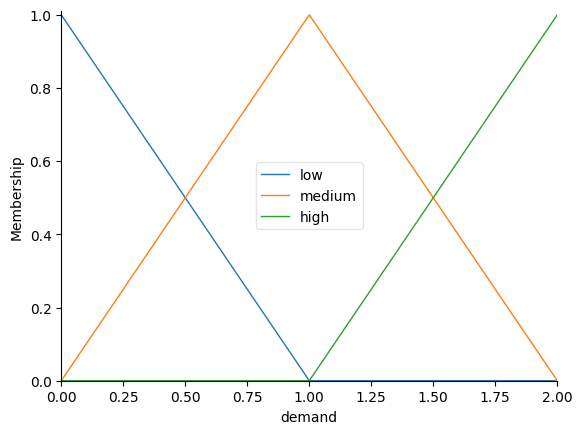

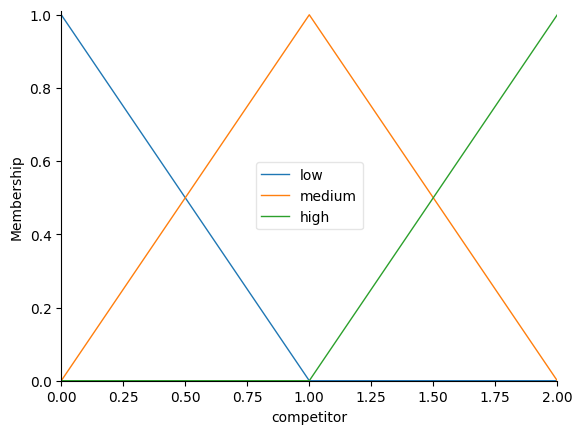

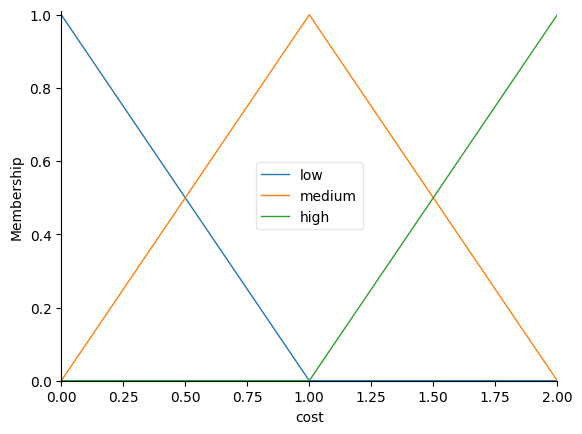

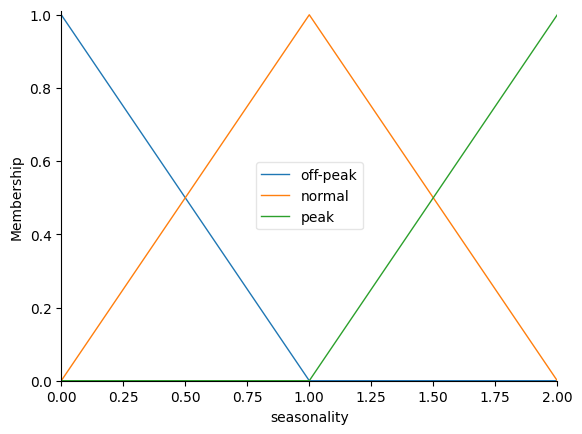

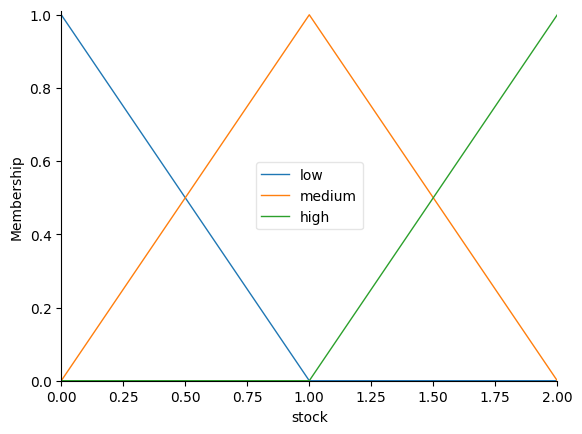

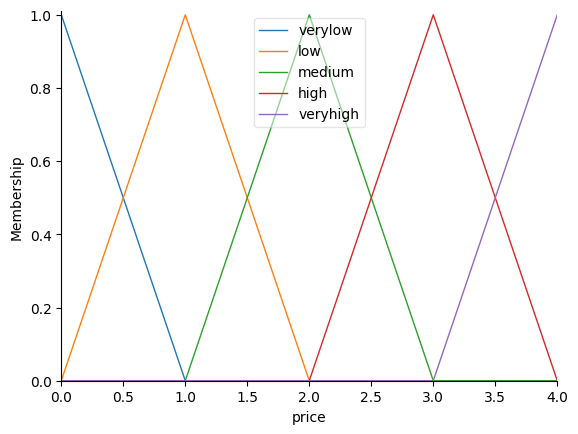

In [19]:
demand.view()
competitor.view()
cost.view()
seasonality.view()
stock.view()
price.view()

In [21]:
rule1=ctrl.Rule(demand['high']&competitor['high']&stock['low'],price['veryhigh'])
rule2=ctrl.Rule(demand['high']&seasonality['peak']&stock['low'],price['veryhigh'])
rule3=ctrl.Rule(demand['medium']&cost['high']&stock['high'],price['veryhigh'])
#
rule4=ctrl.Rule(demand['high']&competitor['medium']&stock['medium'],price['high'])
rule5=ctrl.Rule(demand['medium']&competitor['high']&stock['low'],price['high'])
rule6=ctrl.Rule(demand['medium']&competitor['high']&stock['low'],price['high'])
rule7=ctrl.Rule(demand['high']&seasonality['peak']&stock['medium'],price['high'])

#
rule8=ctrl.Rule(demand['medium']&competitor['medium']&stock['medium'],price['medium'])
rule9=ctrl.Rule(demand['low']&competitor['high']&stock['medium'],price['medium'])
rule10=ctrl.Rule(demand['medium']&cost['medium']&stock['medium'],price['medium'])
#
rule11=ctrl.Rule(demand['low']&competitor['low']&stock['high'],price['low'])
rule12=ctrl.Rule(demand['medium']&cost['low']&stock['high'],price['low'])
rule13=ctrl.Rule(demand['low']&seasonality['off-peak']&stock['high'],price['low'])
#
rule14=ctrl.Rule(demand['low']&competitor['low']&stock['high'],price['verylow'])
rule15=ctrl.Rule(demand['low']&seasonality['off-peak']&stock['high'],price['verylow'])
rule16=ctrl.Rule(demand['medium']&competitor['low']&stock['high'],price['verylow'])


2.2947368421052627


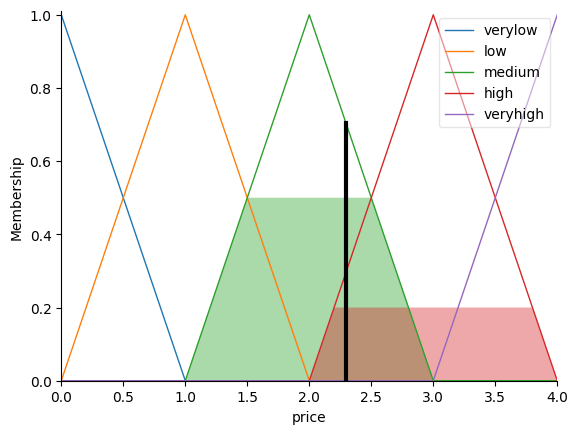

In [23]:
price_ctrl=ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8,rule9,rule10,rule11,rule12,rule13,rule14,rule15,rule16])
price_sim=ctrl.ControlSystemSimulation(price_ctrl)
price_sim.input['demand']=1.5
price_sim.input['competitor']=2
price_sim.input['cost']=0.5
price_sim.input['seasonality']=1.2
price_sim.input['stock']=1
price_sim.compute()
print(price_sim.output['price'])
price.view(sim=price_sim)